# About this Continuous Assessment
|  |  |
|--|--|
|Assessment| 7|
|Delivery method | Canvas submission of this file after completion |
|Deadline | As specified on Canvas. |
|ILOs|Be able to analyse system behaviour using dynamics model.|

# Allowed packages 
Do not modify these. Do not add or remove packages.

In [ ]:
# Helper functions and packages
%pip install numpy
%pip install matplotlib

# Allowed imports

<div class="alert alert-block alert-info">
Do not modify, add, or remove imports. Do not add imports anywhere else in this notebook.
</div>

In [1]:
# Helper functions and packages
import numpy as np
import matplotlib.pyplot as plt

## Instructions
This assessment is made of 2 tasks. There are two points in total for this part of the assessment.   
Each cell is tagged for the assessment, so do not delete or otherwise tamper with the cells. The assignment is to add content to each of the Python cells as requested.

## Verify the spreadsheet

Your student ID will be used to assign you parameters. For each task, look into your row to see what you must implement.

# Dynamics modelling using Lagrangian Formula
Considering the single-link robot arm shown below, consisting of a rigid link coupled through a gear train to a DC motor.   
Let $\theta_l$ and $\theta_m$ denote the angles of the link and motor shaft respectively. Then $\theta_m = r\theta_l$ where $r$ is the gear ratio.   
Using $\theta_l$ as the generalised coordinate. Assume that the motor torque $u$ remains the same in the generalised coordinate. 

Here are the notations of the system parameters:  
- $u$ denote the torque generated by the motor;   
- $M$ is the link's total mass;   
- $g$ is the gravity acceleration;   
- $l$ is the distance from the center of mass to the rotation axis;   
- $𝐽_𝑚$, $𝐽_𝑙$ are rotational inertias of the motor and link;   
- $B$ is the overall rotational damping coefficient.

  <figure style="margin: 10px; width: 100%; text-align: left;">
    <img src="figures/figure.png" alt='A single-link robot arm.' style="max-width: 100%; height: 250px;"/>
    <figcaption>Figure 1 - A single-link robot arm.</figcaption>
  </figure>

The equation of motion of this single-link robot arm can be represented as $$J_{tr}\ddot{\theta}_l + B \dot{\theta}_l + Mgl\sin \theta_l = u $$  
where $J_{tr}$ is the total inertia of the rotational components.  
The following parameters $l$, $M$, $B$,  $r$, $J_m$ , $J_l$ of the robot arm as well as the initial angle $q_0$ are provided in the spreedsheet. 

In [3]:
# Parameters
g = 9.8
############################################################
# Enter the parameters below
# You can find them in the spreadsheet
B = 0.25   # rotational damping coefficient, Nms/rad
M = 1.5   # the link's total mass, kg
r = 1.5   # gear ratio  
Jm = 0.02 # rotational inertia of the motor, kg*m^2
Jl = 0.15 # rotational inertia of the link, kg*m^2
l = 0.3   # distance from the center of mass to the rotation axis, m
q0 = 60  # initial angle in degree
############################################################

---
## ✏️ Task 1. System Lagrangian
Assume that the link is initially at position $q_0$ (as defined earlier) and begins motion with zero initial angular velocity. 

Define the zero potential energy at the lowest position of the link. 

Calculate the Lagrangian of the system at the initial position. (1 pt)

In [4]:
# Code for Task 1
######################################################################################
# Enter your code here
# TODO:

q0_rad = np.deg2rad(q0)
# Kinetic energy at initial position (zero velocity)
T = 0.0
# Potential energy: V = Mgl(1 - cos(theta)), with zero at lowest pos (theta=0)
V = M * g * l * (1 - np.cos(q0_rad))
# Lagrangian L = T - V
L = T - V
# Convert initial angle to radians
q0_rad = np.deg2rad(q0)
# Kinetic energy at initial position (zero velocity)
T = 0.0
# Potential energy: V = Mgl(1 - cos(theta)), with zero at lowest pos (theta=0)
V = M * g * l * (1 - np.cos(q0_rad))
# Lagrangian L = T - V
L = T - V
######################################################################################
print(f'The Lagrangian of this system at the initial position is {L}')

# Marking variables (don't modify)
ansT1_L = L

The Lagrangian of this system at the initial position is -2.2049999999999996


---
## ✏️ Task 2. System motion
Assume that the motor torque has the following Sigmoid profile: $$u(t) = \frac{1}{1+e^{-t}}. $$  
Setting the time step $dt$ as 0.01 s, simulate the response of the link for the time period [0, 10] seconds. 

Obtain the *angles* of the link movement versus time by completing the following code.   (1 pt) 
 


In [5]:
# Code for Task 2
dt = 0.01                           # time step
tf = 10.0                           # simulation duration
t = np.arange(0, tf+dt, dt)         # define the time-series array
q = np.zeros((len(t)))              # define the array for link angle
q_dot = np.zeros((len(t)))          # define the array for angular velocity
q_ddot = np.zeros((len(t)))         # define the array for angular acceleration

J_tr = r**2*Jm+Jl     # Define the total rotational inertia of the system

def eom_1dofmanipulator(q,q_dot,u,J_tr,B,M,g,l):
    '''
    This function has three inputs:
    q is a scalar, representing the current angle
    q_dot is a scalar, representing the current angular velocity
    u is a scalar, representing the motor torque
    J, B, M, g, l are all scalar system parameters
    The output of this function is q_ddot, which is the angular acceleration of the link
    '''    
    ############################################################
    # Enter your code here
    # Define the accleration of the link
    # TODO:
    q_ddot = (u - B*q_dot - M*g*l*np.sin(q)) / J_tr
    ############################################################
    return q_ddot

def euler_integration(q_old, q_dot,dt):
    # This function is to calculate the angle of the link for the next time step
    # given the angle of the current time step, and the current angular velocity
    # by using Euler integration method.
    q_new = q_old+q_dot*dt
    return q_new


############################################################
# Enter your code here
# Define initial conditions
# TODO:
q[0] = np.deg2rad(q0)   # in radian
q_dot[0] = 0
q_ddot[0] = eom_1dofmanipulator(q[0], q_dot[0], 1/(1+np.exp(-t[0])), J_tr, B, M, g, l)
############################################################

# Simulation loop
for idx in range(len(t) - 1):
    ############################################################
     # Enter your code here
    # TODO:
    # Define your motor toque
    u = 1/(1+np.exp(-t[idx])) 
    # Calculate the acceleration
    # you defined earlier
    q_ddot[idx+1] = eom_1dofmanipulator(q[idx], q_dot[idx], u, J_tr, B, M, g, l)  
    ############################################################    
    # Update the angular velocity and angle
    q_dot[idx+1] = euler_integration(q_dot[idx], q_ddot[idx+1], dt)
    q[idx+1] = euler_integration(q[idx],q_dot[idx+1], dt)

# Marking variables (don't modify)
ansT2_q = q


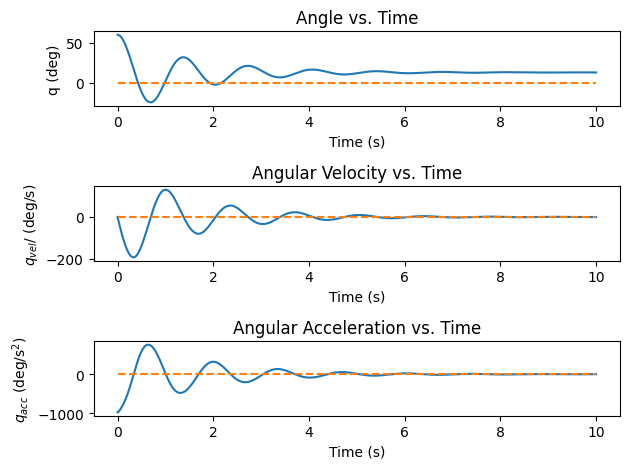

In [6]:
q_ddot_deg = q_ddot*180/np.pi  # Convert the accleration from radius/s^2 to degree/s^2 
q_dot_deg = q_dot*180/np.pi    # Convert the accleration from radius/s to degree/s
q_deg = q*180/np.pi            # Convert the accleration from radius to degree
plt.figure()
plt.subplot(311)
plt.plot(t, q_deg)
plt.plot(t,np.linspace(0, 0, len(t)),linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('q (deg)')
plt.title('Angle vs. Time')

plt.subplot(312)
plt.plot(t, q_dot_deg)
plt.plot(t,np.linspace(0, 0, len(t)),linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('$q_{vel}$/ (deg/s)')
plt.title('Angular Velocity vs. Time')

plt.subplot(313)
plt.plot(t, q_ddot_deg)
plt.plot(t,np.linspace(0, 0, len(t)),linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('$q_{acc}$ (deg/s$^2$)')
plt.title('Angular Acceleration vs. Time')

plt.tight_layout()
plt.show() 